#### 손가락 숫자 모양의 Image 분류

#### Data 불러오기

In [177]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [178]:
train_images = glob.glob("../Data/fingers/train/*.png")
test_images = glob.glob("../Data/fingers/test/*.png")

In [179]:
# file name 확인
train_images[:5]

['../Data/fingers/train\\00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '../Data/fingers/train\\000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '../Data/fingers/train\\000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '../Data/fingers/train\\000d9961-8136-4dee-9820-86e178777958_0L.png',
 '../Data/fingers/train\\0010095b-2e3d-4517-a511-1f688c378f96_5L.png']

In [180]:
# file name 확인
test_images[:5]

['../Data/fingers/test\\000e7aa6-100b-4c6b-9ff0-e7a8e53e4465_5L.png',
 '../Data/fingers/test\\001f6021-8581-4ed2-aed4-cda0af1d5d57_5L.png',
 '../Data/fingers/test\\0027029b-4c3c-4785-bc1b-b8141331a108_3R.png',
 '../Data/fingers/test\\004599fb-c735-4ff3-a969-342dda319382_5L.png',
 '../Data/fingers/test\\00500e1a-f4bd-4f66-9eb8-c7fce19a3f6f_5L.png']

In [181]:
# 갯수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [182]:
# train_data와 test data 만들기: 128*128 -> 32*32
train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    train_input.append(imgResize)
    train_target.append(image[-6:-4])

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

In [183]:
# Target Data 확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


In [184]:
import matplotlib.pyplot as plt

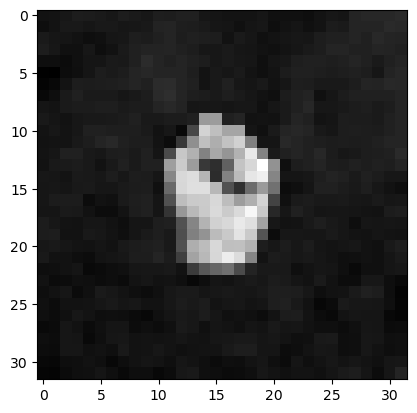

In [185]:
# train의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()


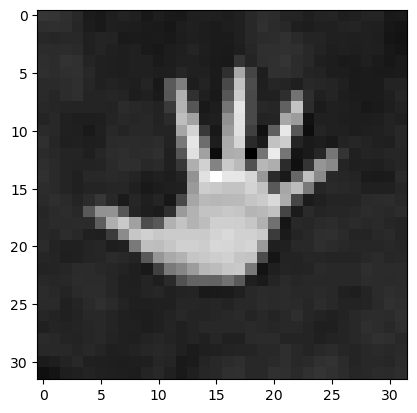

In [186]:
# test의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

In [187]:
import numpy as np

In [188]:
# train Data 만들기 (18000 * 32 * 32)

tempData = np.zeros(
        18000 * 32 * 32,
        dtype=np.int32
).reshape(18000, 32, 32)

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

train_input = tempData.copy()

In [189]:
# test Data 만들기 (3600 * 32 * 32)

tempData = np.zeros(
        3600 * 32 * 32,
        dtype=np.int32
).reshape(3600, 32, 32)

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

test_input = tempData.copy()

In [190]:
# 배열 크기 확인
print(train_input.shape, test_input.shape)

(18000, 32, 32) (3600, 32, 32)


In [191]:
train_input[0]

array([[51, 52, 55, ..., 66, 66, 68],
       [48, 52, 56, ..., 64, 68, 67],
       [57, 54, 53, ..., 67, 65, 63],
       ...,
       [47, 46, 54, ..., 51, 48, 50],
       [44, 43, 48, ..., 50, 54, 55],
       [42, 41, 46, ..., 47, 54, 64]], shape=(32, 32), dtype=int32)

----
#### Target을 숫자로 변경하기

In [192]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

In [193]:
# Train_Target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [194]:
# Test_Target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [195]:
train_target[:5]

[6, 6, 8, 6, 11]

In [196]:
test_target[:5]

[11, 11, 3, 11, 11]

In [197]:
# Target도 numpy배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

train_target[:5]

array([ 6,  6,  8,  6, 11])

In [198]:
test_target

array([11, 11,  3, ...,  4,  3,  3], shape=(3600,))

#### Deep Learning 구성하기

In [199]:
train_scaled = train_input / 255.0

In [200]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

 
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(   
        train_scaled,
        train_target,
        test_size = 0.2,    
        random_state=42
    )

In [201]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=train_scaled.shape[1:]))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(12, activation='softmax'))

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [202]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,572 (2.63 MB)

 Trainable params: 690,572 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [203]:
# 손실함수
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [209]:
# 학습하기
model.fit(
    train_scaled,
    train_target,
    batch_size=32,
    epochs = 4
)

Epoch 1/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9876 - loss: 0.0336
Epoch 2/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9982 - loss: 0.0069
Epoch 3/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9935 - loss: 0.0226
Epoch 4/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9911 - loss: 0.0289


In [210]:
# 테스트 데이터
test_scaled = test_input / 255.0

# 테스트로 확인
print('Train:' , model.evaluate(train_scaled, train_target))
print('Valid:' , model.evaluate(val_scaled, val_target))
print('Test:' , model.evaluate(test_scaled, test_target))

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9788 - loss: 0.0568
Train: [0.05680936202406883, 0.9788194298744202]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9769 - loss: 0.0604
Valid: [0.06040750816464424, 0.9769444465637207]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9769 - loss: 0.0547
Test: [0.054678842425346375, 0.9769444465637207]


In [214]:
int_to_label = {v: k for k, v in label_to_int.items()}
# 각 이미지별 12개 클래스 확률 반환 (shape: 테스트 이미지 개수, 12)
predictions = model.predict(test_scaled)

# 가장 높은 확률을 가진 인덱스(0~11) 추출
predicted_labels = np.argmax(predictions, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [215]:
# -------------------------------------------------------------
# 역방향 딕셔너리를 이용해 숫자를 문자열로 변환
# -------------------------------------------------------------
# 리스트 컴프리헨션을 이용해 예측된 숫자 배열을 원래 손가락 모양 문자열로 바꿉니다.
predicted_string_labels = [int_to_label[idx] for idx in predicted_labels]

# 실제 정답(y_test)도 숫자로 되어있을 테니 비교를 위해 문자열로 바꿉니다.
real_string_labels = [int_to_label[idx] for idx in test_target]


     [실제 정답]  vs  [모델의 예측값]
샘플 [0]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [1]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [2]: 실제 정답 = 3R  |  모델 예측 = 3R
샘플 [3]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [4]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [5]: 실제 정답 = 4R  |  모델 예측 = 4R
샘플 [6]: 실제 정답 = 2R  |  모델 예측 = 2R
샘플 [7]: 실제 정답 = 4R  |  모델 예측 = 4R
샘플 [8]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [9]: 실제 정답 = 4R  |  모델 예측 = 4R
샘플 [10]: 실제 정답 = 1L  |  모델 예측 = 1L
샘플 [11]: 실제 정답 = 0L  |  모델 예측 = 0L
샘플 [12]: 실제 정답 = 5R  |  모델 예측 = 5R
샘플 [13]: 실제 정답 = 1R  |  모델 예측 = 1R
샘플 [14]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [15]: 실제 정답 = 1L  |  모델 예측 = 1L
샘플 [16]: 실제 정답 = 0L  |  모델 예측 = 0L
샘플 [17]: 실제 정답 = 5L  |  모델 예측 = 5L
샘플 [18]: 실제 정답 = 0R  |  모델 예측 = 0L
샘플 [19]: 실제 정답 = 5R  |  모델 예측 = 5R


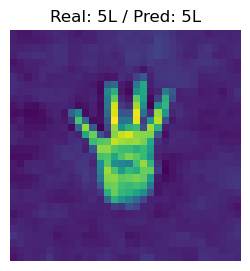

In [216]:
# -------------------------------------------------------------
# 4. 결과 출력 및 확인
# -------------------------------------------------------------
print("\n" + "="*50)
print("     [실제 정답]  vs  [모델의 예측값]")
print("="*50)
for i in range(20):
    print(f"샘플 [{i}]: 실제 정답 = {real_string_labels[i]}  |  모델 예측 = {predicted_string_labels[i]}")
print("="*50)

# 시각화 확인 (첫 번째 테스트 이미지)
plt.figure(figsize=(3, 3))
plt.imshow(train_scaled[0])
plt.title(f"Real: {real_string_labels[0]} / Pred: {predicted_string_labels[0]}")
plt.axis('off')
plt.show()